# Notebook 5 — Vedere lo shift (MNIST) &nbsp; ⟵ *il cuore*

**Concetto.** Nel NB3 abbiamo isolato l'**epistemica** come parte dell'incertezza che
cresce fuori dal manifold source. Qui dimostriamo il meccanismo **dove la verità è nota**,
così da poterci fidare del segnale prima di applicarlo a dati reali (NB5).

Due esperimenti:
- **(a) OOD netto** — Fashion-MNIST come fuori-distribuzione: l'epistemica come *rivelatore*
  (AUROC) e come criterio di *rigetto* (accuratezza vs copertura).
- **(b) Shift graduale** — Rotated-MNIST: ruotiamo le cifre di un angolo crescente.
  L'angolo **è** la magnitudo dello shift (verità nota), quindi non serve alcun proxy:
  se l'epistemica media **cresce monotona con l'angolo**, il meccanismo funziona.

Riusiamo il modello bayesiano source del NB2 (CNN congelata + posterior della testa).

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # evita OMP Error #15 (Windows)

import sys, pathlib
here = pathlib.Path.cwd()
for base in [here, *here.parents]:
    if (base / "src").is_dir():
        sys.path.insert(0, str(base)); PROJ = base; break
else:
    raise RuntimeError("cartella 'src' non trovata: apri il progetto dalla sua root")
import numpy as np, torch
import matplotlib.pyplot as plt
import torchvision, torchvision.transforms.functional as TF
from src.bayesian_model import SmallCNN, extract, augment, LastLayerLaplace
from src.metrics import auroc, rejection_curve

np.random.seed(0); torch.manual_seed(0); RNG = np.random.default_rng(0)
DATA = PROJ / "data"

## Carico il modello bayesiano source (NB2)

In [2]:
model = SmallCNN(n_classes=10)
model.load_state_dict(torch.load(DATA / "mnist_cnn.pt")); model.eval()
d = np.load(DATA / "mnist_laplace.npz")
laplace = LastLayerLaplace(theta_map=d["theta_map"], cov=d["cov"], K=int(d["K"]), Dp=int(d["Dp"]))
print("modello + posterior caricati dal NB2")

modello + posterior caricati dal NB2


/var/folders/_9/1xfdfmn92_s0ykk0h7w8bwtc0000gn/T/ipykernel_28933/2298215054.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(DATA / "mnis

## (a) Fashion-MNIST come OOD: rivelatore e rigetto

Calcoliamo total/aleatoria/epistemica su MNIST (in-dist) e Fashion (OOD). Un buon
rivelatore OOD deve dare **AUROC alto** usando l'incertezza come score. Confrontiamo
l'epistemica con l'aleatoria: deve vincere l'epistemica.

In [3]:
import torchvision.transforms as T
tf = T.ToTensor()
from torch.utils.data import DataLoader, Subset
mnist = torchvision.datasets.MNIST(str(DATA), train=False, download=True, transform=tf)
fashion = torchvision.datasets.FashionMNIST(str(DATA), train=False, download=True, transform=tf)
ml = DataLoader(Subset(mnist, range(2000)), batch_size=1024)
fl = DataLoader(Subset(fashion, range(2000)), batch_size=1024)

Phi_m, y_m, logit_m = extract(model, ml)
Phi_f, _,   _       = extract(model, fl)
pm = laplace.predictive(augment(Phi_m), M=200, rng=RNG)
pf = laplace.predictive(augment(Phi_f), M=200, rng=RNG)

scores = np.concatenate([pm["epistemic"], pf["epistemic"]])
labels = np.concatenate([np.zeros(len(pm["epistemic"])), np.ones(len(pf["epistemic"]))])
sc_al  = np.concatenate([pm["aleatoric"], pf["aleatoric"]])
print(f"AUROC epistemica (OOD): {auroc(scores, labels):.3f}")
print(f"AUROC aleatoria  (OOD): {auroc(sc_al,  labels):.3f}   (attesa peggiore)")

AUROC epistemica (OOD): 0.969
AUROC aleatoria  (OOD): 0.940   (attesa peggiore)


L'epistemica separa Fashion da MNIST molto meglio dell'aleatoria: è il segnale giusto.
Ora usiamola per **rifiutare** i punti incerti su MNIST: tenendo solo la frazione a più
bassa incertezza, l'accuratezza deve salire.

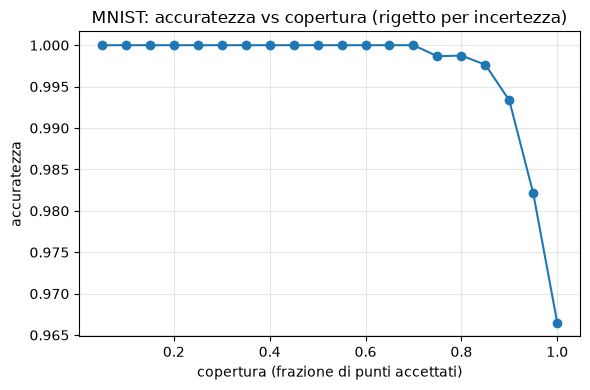

acc tutto (cov=1.0): 0.967   acc top-20% piu fidati: 1.000


In [4]:
correct = (logit_m.argmax(1) == y_m)
cov, acc = rejection_curve(pm["total"], correct, n_points=20)

plt.figure(figsize=(6,4))
plt.plot(cov, acc, "o-")
plt.xlabel("copertura (frazione di punti accettati)"); plt.ylabel("accuratezza")
plt.title("MNIST: accuratezza vs copertura (rigetto per incertezza)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"acc tutto (cov=1.0): {acc[-1]:.3f}   acc top-20% piu fidati: {acc[int(0.2*len(acc))-1]:.3f}")

## (b) Rotated-MNIST: epistemica vs angolo **noto**

Ruotiamo le stesse immagini MNIST di angoli crescenti. Qui **non serve un proxy dello
shift**: l'angolo di rotazione è la verità. Ci aspettiamo che l'epistemica media cresca
in modo monotono con l'angolo, mentre l'accuratezza crolla.

In [5]:
imgs = mnist.data[:2000].float() / 255.0     # (N,28,28) in [0,1]
ys   = mnist.targets[:2000].numpy()
angles = [0, 15, 30, 45, 60, 75, 90]

epi, accs = [], []
for deg in angles:
    x = TF.rotate(imgs.unsqueeze(1), deg)                 # ruota tutte le immagini
    with torch.no_grad():
        phi = model.features(x).numpy(); logit = model(x).numpy()
    pr = laplace.predictive(augment(phi), M=100, rng=RNG)
    epi.append(pr["epistemic"].mean()); accs.append((logit.argmax(1) == ys).mean())

for deg, e, a in zip(angles, epi, accs):
    print(f"angolo {deg:>2}°  epistemica={e:.3f}  accuratezza={a:.3f}")

angolo  0°  epistemica=0.011  accuratezza=0.967
angolo 15°  epistemica=0.021  accuratezza=0.925
angolo 30°  epistemica=0.059  accuratezza=0.744
angolo 45°  epistemica=0.098  accuratezza=0.442
angolo 60°  epistemica=0.105  accuratezza=0.242
angolo 75°  epistemica=0.111  accuratezza=0.183
angolo 90°  epistemica=0.123  accuratezza=0.147


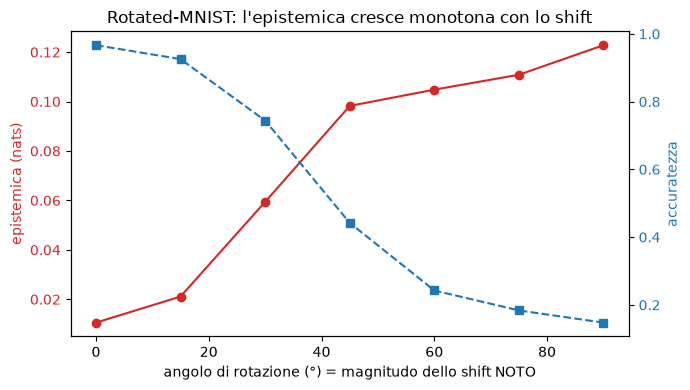

epistemica monotona crescente con l'angolo: True


In [6]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(angles, epi, "o-", color="tab:red", label="epistemica media")
ax1.set_xlabel("angolo di rotazione (°) = magnitudo dello shift NOTO")
ax1.set_ylabel("epistemica (nats)", color="tab:red"); ax1.tick_params(axis="y", labelcolor="tab:red")
ax2 = ax1.twinx()
ax2.plot(angles, accs, "s--", color="tab:blue", label="accuratezza")
ax2.set_ylabel("accuratezza", color="tab:blue"); ax2.tick_params(axis="y", labelcolor="tab:blue")
plt.title("Rotated-MNIST: l'epistemica cresce monotona con lo shift")
fig.tight_layout(); plt.show()

mono = all(epi[i] <= epi[i+1] + 1e-9 for i in range(len(epi)-1))
print("epistemica monotona crescente con l'angolo:", mono)

## Riassunto

- **(a)** L'epistemica è un buon **rivelatore OOD** (AUROC ≫ aleatoria) e un buon criterio
  di **rigetto** (accuratezza sale scartando i punti incerti).
- **(b)** Su Rotated-MNIST, con lo shift **noto** (l'angolo), l'epistemica media **cresce
  monotona** mentre l'accuratezza crolla: il meccanismo "epistemica ~ distanza dal manifold
  source" è confermato in condizioni controllate.

Avendo validato il segnale dove la verità è nota, nel **Notebook 6** lo verifichiamo su
dati reali (UCI-HAR), dove la verità sullo shift **non** c'è e serve un proxy.